# Importar librerias

In [25]:
import tensorflow as tf
import numpy as np
import cv2
import numpy as np
import matplotlib.pyplot as plt

* img size transforma las imagenes a un tama;o en especifico facilitando el proceso
* batch size se dedice cuantas imagenes se procesan


In [11]:
IMG_SIZE = 224
BATCH_SIZE = 16

trainData = tf.keras.utils.image_dataset_from_directory(
    "/home/zanila/PycharmProjects/Ossa/dataset/aloVeraDataSet/crop_images",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)
valData = tf.keras.utils.image_dataset_from_directory(
    "/home/zanila/PycharmProjects/Ossa/dataset/aloVeraDataSet/crop_images",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

Found 3495 files belonging to 3 classes.
Using 2796 files for training.
Found 3495 files belonging to 3 classes.
Using 699 files for validation.


E0000 00:00:1777838227.651286   35537 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Usamos un modelo ya entrenado con imagenet

In [13]:
baseModelAloeVera = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet",
)
baseModelAloeVera.trainable = False


Normalizacion de las imagenes y configuracion del entrenamiento

In [14]:
modelAloeVera = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./ 255),
    baseModelAloeVera,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(3, activation="softmax")
])
modelAloeVera.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Entrenamos el modelo

In [ ]:
historyAloeVera = modelAloeVera.fit(
    trainData,
    validation_data=valData,
    epochs=10,
)

Epoch 1/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 32s 365ms/step - accuracy: 0.9928 - loss: 0.0197 - val_accuracy: 0.9657 - val_loss: 0.1356
Epoch 2/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 33s 377ms/step - accuracy: 0.9914 - loss: 0.0188 - val_accuracy: 0.9714 - val_loss: 0.1158
Epoch 3/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 33s 381ms/step - accuracy: 0.9900 - loss: 0.0311 - val_accuracy: 0.9614 - val_loss: 0.1310
Epoch 4/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 35s 394ms/step - accuracy: 0.9900 - loss: 0.0281 - val_accuracy: 0.9428 - val_loss: 0.2880
Epoch 5/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 34s 387ms/step - accuracy: 0.9861 - loss: 0.0307 - val_accuracy: 0.9542 - val_loss: 0.1654
Epoch 6/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 34s 386ms/step - accuracy: 0.9825 - loss: 0.0475 - val_accuracy: 0.9413 - val_loss: 0.2918
Epoch 7/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 35s 393ms/step - accuracy: 0.9900 - loss: 0.0310 - val_accuracy: 0.9599 - val_loss: 0.1517
Epoch 8/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 37s 418ms/step - accuracy: 0.9900 - loss: 0.0291 - val_accu

Guardamos el modelo

In [16]:
modelAloeVera.save("aloeVeraModel.keras")

Probamos el modelo

In [17]:
model = tf.keras.models.load_model("/home/zanila/PycharmProjects/Ossa/aloeVeraModel.keras")

#OpenCV

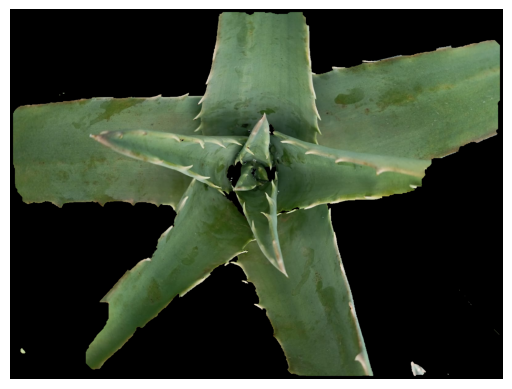

In [36]:
img = cv2.imread("test.jpeg")

mask = np.zeros(img.shape[:2], np.uint8)

bgdModel = np.zeros((1,65), np.float64)
fgdModel = np.zeros((1,65), np.float64)

rect = (10, 10, img.shape[1]-20, img.shape[0]-20)

cv2.grabCut(
    img,
    mask,
    rect,
    bgdModel,
    fgdModel,
    5,
    cv2.GC_INIT_WITH_RECT
)

mask2 = np.where(
    (mask == 2) | (mask == 0),
    0,
    1
).astype("uint8")

result = img * mask2[:, :, np.newaxis]

result = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

plt.imshow(result)
plt.axis("off")
plt.show()
result_resized = cv2.resize(result, (224, 224))
imagenArray = tf.keras.utils.img_to_array(result_resized)

In [37]:
imagenArray = tf.expand_dims(result_resized, 0)

In [38]:
predictions = model.predict(imagenArray)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


In [39]:
print(predictions)
informacion = trainData.class_names


[[5.6120096e-04 1.1938153e-01 8.8005728e-01]]


Predccion:  rust
Confianza: 53.13 %


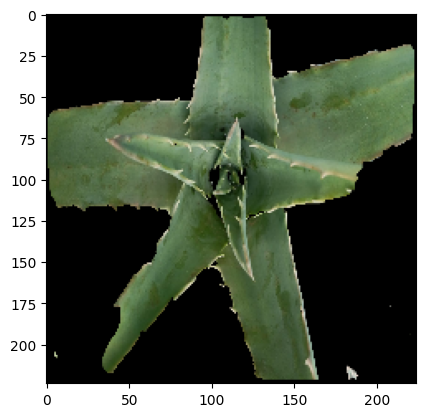

In [40]:
score = tf.nn.softmax(predictions[0])
plt.imshow(result_resized)
print("Predccion: ",
      informacion[np.argmax(score)])
print(
    "Confianza:",
    round(100 * np.max(score), 2),
    "%"
)